In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_breast_cancer

In [3]:
data = load_breast_cancer()

data

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [4]:
X = data.data
y = data.target

In [5]:
X

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]])

In [6]:
print("Features Name", data.feature_names)

Features Name ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [7]:
# Split Data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
X.shape

(569, 30)

In [9]:
np.zeros(30)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [13]:
# Logistic Regression

class LogisticRegression:
  def __init__(self, lr = 0.001, n_iters = 1000):
    self.lr = lr
    self.epochs = n_iters

  def sigmoid (self, z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

  def fit(self, X, y):
    self.w = np.zeros(X.shape[1])         # Weights intialization
    self.b = 0                            # intialize

    for _ in range(self.epochs):
      linear = np.dot(X, self.w) + self.b
      y_pred = self.sigmoid(linear)

      error = y_pred - y

      dw = (1/len(y)) * np.dot(X.T, error)
      db = (1/len(y)) * np.sum(error)

      self.w -= self.lr * dw
      self.b -= self.lr * db

  def predict(self, X):
    linear = np.dot(X, self.w) + self.b
    y_pred = self.sigmoid(linear)
    return [1 if i > 0.5 else 0 for i in y_pred]

In [14]:
model = LogisticRegression()

In [15]:
model.fit(X_train, y_train)

In [16]:
model.predict(X_test)

[0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 0]

In [23]:
# Evaluation of model

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix)

def evaluate(y_test, y_pred):
  print("Accuracy Score: ", accuracy_score(y_test, model.predict(X_test)))
  print("Precision score :", precision_score(y_test, model.predict(X_test)))
  print("Recall Score: ", recall_score(y_test, model.predict(X_test)))
  print("F1 Score: ", f1_score(y_test, model.predict(X_test)))
  print("Confusion Matrix: \n", confusion_matrix(y_test, model.predict(X_test)))

In [ ]:
evaluate (y_test, model.predict(X_test))

<Axes: >

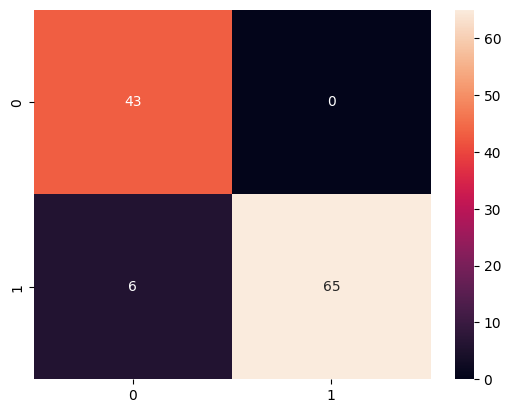

In [18]:
import seaborn as sns

sns.heatmap(confusion_matrix(y_test, model.predict(X_test)), annot=True)

In [19]:
# From sklearn

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [20]:
y_pred = model.predict(X_test)

In [24]:
evaluate(y_test, y_pred)

Accuracy Score:  0.956140350877193
Precision score : 0.9459459459459459
Recall Score:  0.9859154929577465
F1 Score:  0.9655172413793104
Confusion Matrix: 
 [[39  4]
 [ 1 70]]


In [30]:
#KNN
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=2)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=2)

In [31]:
evaluate(y_test, model.predict(X_test))

Accuracy Score:  0.9298245614035088
Precision score : 0.9565217391304348
Recall Score:  0.9295774647887324
F1 Score:  0.9428571428571428
Confusion Matrix: 
 [[40  3]
 [ 5 66]]


In [38]:
# KNN Manual

class KNN:
  def __init__(self, k=5):
    self.k = k
# Trainig
  def fit(self, X, y):
    self.X_train = X
    self.y_train = y

  def predict(self, X):
    predictions = []

    for x in X:
      # COmpute distance ( euclidean )
      distances = np.array([np.sqrt(np.sum((x - x_train) ** 2 ))for x_train in self.X_train])

      # K Neighbours

      k_indices = np.argsort(distances)[:self.k]
      # Labels
      k_nearest_labels = self.y_train[k_indices]

      # Voting
      labels, counts = np.unique(k_nearest_labels, return_counts=True)

      prediction = labels[np.argmax(counts)]

      predictions.append(prediction)

    return np.array(predictions)

In [39]:
model = KNN()
model.fit(X_train, y_train)

In [40]:
evaluate(y_test, model.predict(X_test))

Accuracy Score:  0.956140350877193
Precision score : 0.9342105263157895
Recall Score:  1.0
F1 Score:  0.9659863945578231
Confusion Matrix: 
 [[38  5]
 [ 0 71]]
